In [6]:
import pandas as pd
import numpy as np
import os

# 1. Identify the correct path to your data folder
# If your notebook is in 'notebooks/' and data is in 'data/', '../data/' is correct.
# If this fails, replace '../data/' with the full path (e.g., r'C:\Users\...\data')
data_path = 'C:\Users\HP\OneDrive\Desktop\climate-challenge-week0\climate-challenge-week0\data' 

countries = ['ethiopia', 'kenya', 'tanzania', 'sudan', 'nigeria']
all_dfs = []

print("Starting file load...")

for country in countries:
    # Construct the filename carefully
    file_name = f"{country}_clean.csv"
    full_file_path = os.path.join(data_path, file_name)
    
    if os.path.exists(full_file_path):
        temp_df = pd.read_csv(full_file_path)
        # Add a column to identify which country the data belongs to
        temp_df['Country'] = country.capitalize()
        all_dfs.append(temp_df)
        print(f"Successfully loaded: {file_name}")
    else:
        print(f"❌ Error: Could not find {full_file_path}")

# 2. Combine all dataframes into one master table
if all_dfs:
    combined_df = pd.concat(all_dfs, ignore_index=True)
    
    # 3. Ensure the DATE column is in datetime format
    combined_df['DATE'] = pd.to_datetime(combined_df['DATE'])
    
    print("\nAll datasets combined successfully!")
    display(combined_df.head())
else:
    print("\nNo data was loaded. Please check your folder paths.")

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (3705172766.py, line 8)

In [7]:
import os
import pandas as pd

# 1. Print current location
print("Python is currently looking in:", os.getcwd())

# 2. Tell Python exactly where the 'data' folder is
# Replace the path below with the location of your 'data' folder.
# To get this, right-click your 'data' folder in VS Code -> 'Copy Path'
target_directory = r'C:\Users\HP\OneDrive\Desktop\climate-challenge-week0\climate-challenge-week0\data'

# 3. Change the working directory to that folder
os.chdir(target_directory)
print("Changed directory to:", os.getcwd())

# 4. Now, try reading the file (just the filename, no '../')
df_ethiopia = pd.read_csv('ethiopia_clean.csv')
print("File loaded successfully!")

Python is currently looking in: c:\Users\HP\OneDrive\Desktop\climate-challenge-week0\climate-challenge-week0\notebooks
Changed directory to: C:\Users\HP\OneDrive\Desktop\climate-challenge-week0\climate-challenge-week0\data
File loaded successfully!


In [14]:
countries = ['ethiopia', 'kenya', 'tanzania', 'sudan', 'nigeria']
all_dfs = []

for country in countries:
    file_name = f"{country}_clean.csv"
    
    # We check if the file exists in the current folder
    if os.path.exists(file_name):
        temp_df = pd.read_csv(file_name)
        temp_df['Country'] = country.capitalize()
        all_dfs.append(temp_df)
        print(f"Combined: {country}")
    else:
        print(f" Warning: {file_name} not found in this folder.")

# Merge them all
combined_df = pd.concat(all_dfs, ignore_index=True)

# Convert DATE again just to be safe for the new combined table
combined_df['DATE'] = pd.to_datetime(combined_df['DATE'])

print("\nSuccess! Combined DataFrame is ready for comparison.")
display(combined_df.sample(5)) # Shows 5 random rows from the mix

Combined: ethiopia

Success! Combined DataFrame is ready for comparison.


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,MONTH,Country
152,2015,153,16.06,21.22,11.31,9.91,4.55,75.25,2.11,4.51,76.98,10.79,2015-06-02,6,Ethiopia
3817,2025,165,20.00,28.41,12.66,15.75,3.08,55.47,1.88,4.13,77.02,9.65,2025-06-14,6,Ethiopia
1808,2019,348,13.66,21.03,7.17,13.86,0.08,76.10,2.14,3.37,77.16,9.44,2019-12-14,12,Ethiopia
1874,2020,49,18.15,26.96,10.96,16.00,0.84,54.98,2.73,4.74,77.13,8.62,2020-02-18,2,Ethiopia
2785,2022,229,15.85,20.58,12.36,8.22,5.89,86.39,1.36,2.69,76.84,12.53,2022-08-17,8,Ethiopia


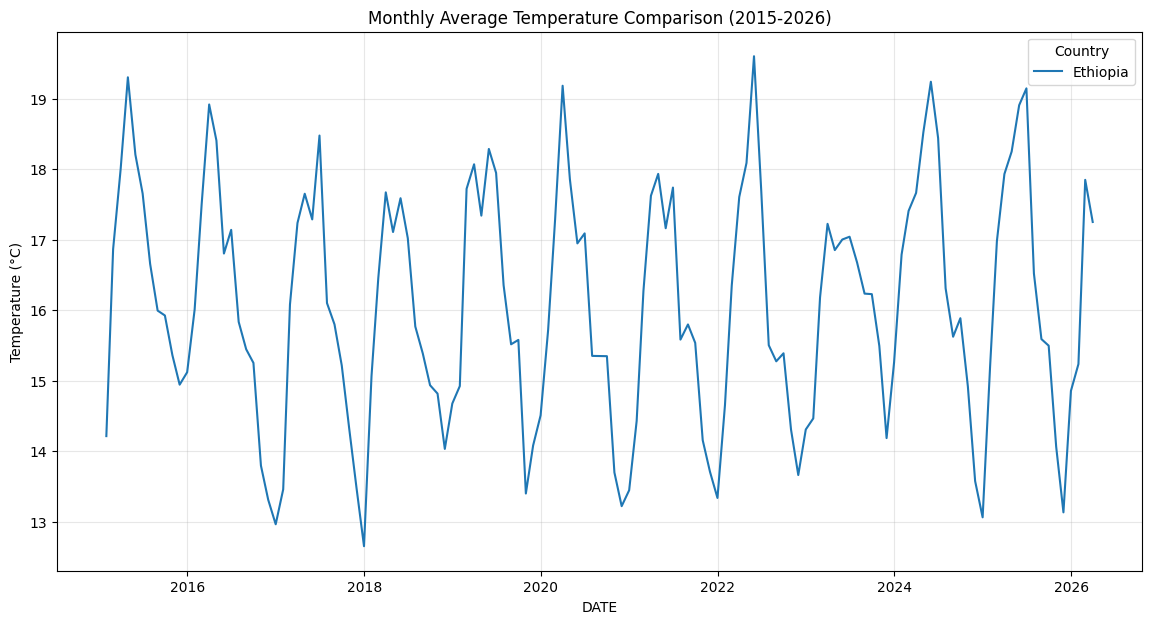

Temperature Summary Table:


,mean,median,std
Country,,,
Ethiopia,16.07,16.04,1.9


In [9]:
# Grouping by Country and Month (using 
monthly_comp = combined_df.set_index('DATE').groupby(['Country', pd.Grouper(freq='ME')]).mean(numeric_only=True).reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_comp, x='DATE', y='T2M', hue='Country')
plt.title('Monthly Average Temperature Comparison (2015-2026)')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.show()

# Summary Table for Temperature
temp_summary = combined_df.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).round(2)
print("Temperature Summary Table:")
display(temp_summary)

C:\Users\HP\AppData\Local\Temp\ipykernel_84020\1454074305.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_df, x='Country', y='PRECTOTCORR', palette='Blues')


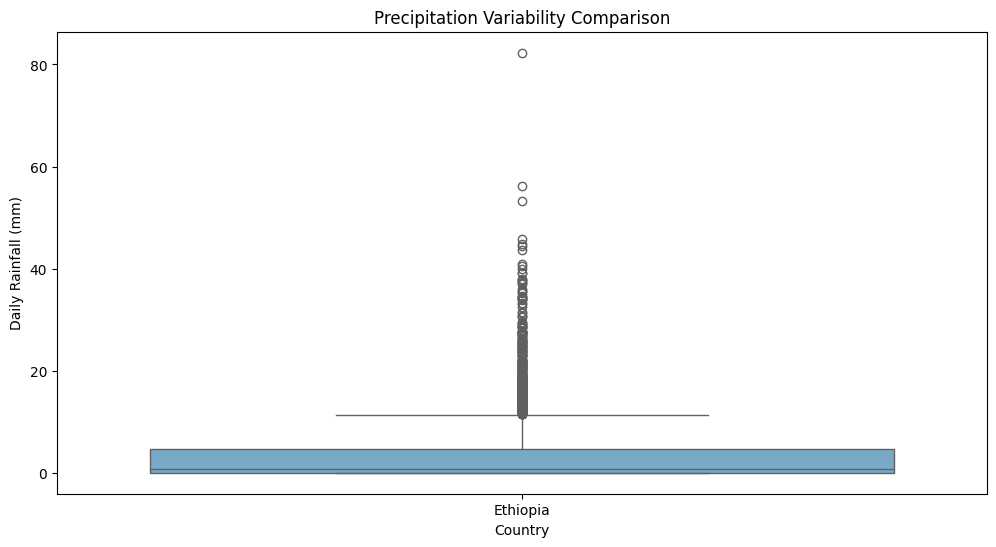

Precipitation Summary Table:


,mean,median,std
Country,,,
Ethiopia,3.63,0.82,6.29


In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=combined_df, x='Country', y='PRECTOTCORR', palette='Blues')
plt.title('Precipitation Variability Comparison')
plt.ylabel('Daily Rainfall (mm)')
plt.show()

# Summary Table for Precipitation
rain_summary = combined_df.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).round(2)
print("Precipitation Summary Table:")
display(rain_summary)

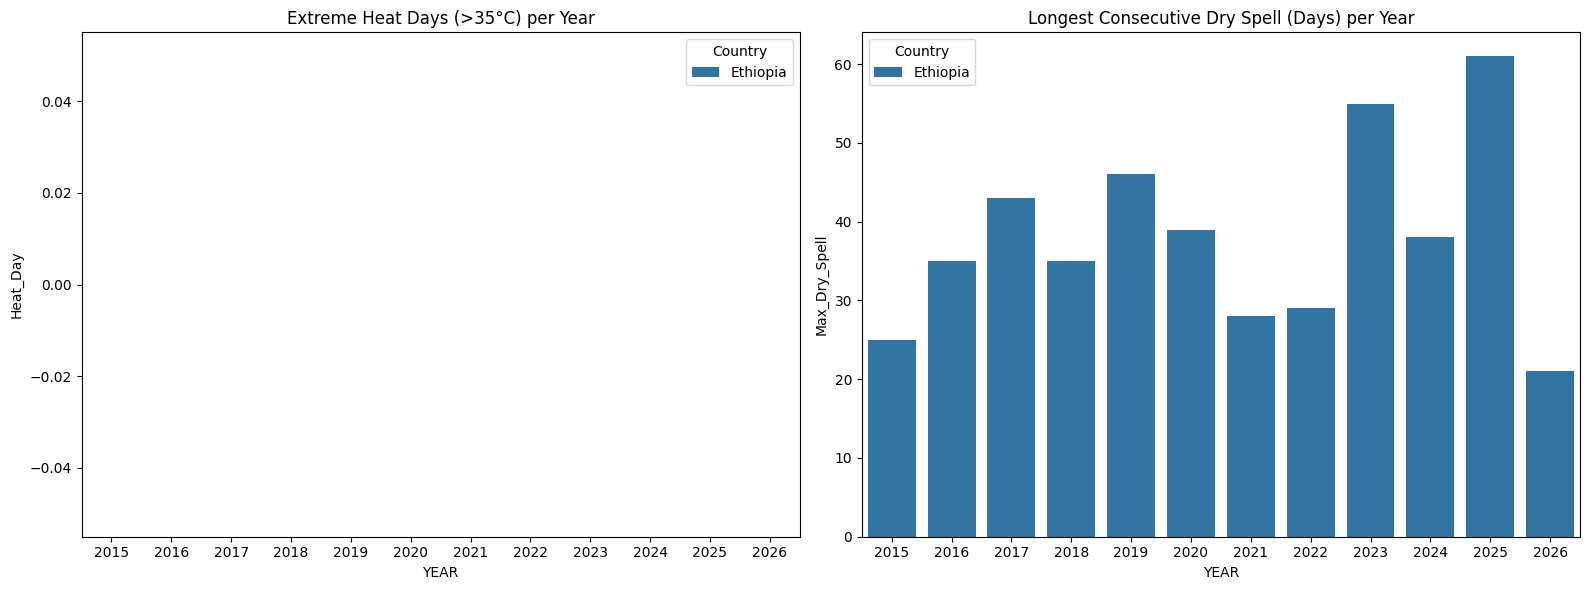

In [12]:
# 1. Extreme Heat: Days where T2M_MAX > 35°C
combined_df['Heat_Day'] = combined_df['T2M_MAX'] > 35
heat_counts = combined_df.groupby(['Country', 'YEAR'])['Heat_Day'].sum().reset_index()

# 2. Consecutive Dry Days (Drought Metric)
def get_max_dry_spell(series):
    is_dry = series < 1
    # Create groups of consecutive True values
    return is_dry.groupby((is_dry != is_dry.shift()).cumsum()).sum().max()

dry_spells = combined_df.groupby(['Country', 'YEAR'])['PRECTOTCORR'].apply(get_max_dry_spell).reset_index()
dry_spells.columns = ['Country', 'YEAR', 'Max_Dry_Spell']

# --- Visualization ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot Heat Days
sns.barplot(data=heat_counts, x='YEAR', y='Heat_Day', hue='Country', ax=ax[0])
ax[0].set_title('Extreme Heat Days (>35°C) per Year')

# Plot Dry Spells
sns.barplot(data=dry_spells, x='YEAR', y='Max_Dry_Spell', hue='Country', ax=ax[1])
ax[1].set_title('Longest Consecutive Dry Spell (Days) per Year')

plt.tight_layout()
plt.show()

In [13]:
from scipy.stats import f_oneway

# Extract T2M for each country group
groups = [combined_df[combined_df['Country'] == c]['T2M'] for c in countries]

f_stat, p_val = f_oneway(*groups)

print(f"--- Statistical Significance Test (T2M) ---")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

if p_val < 0.05:
    print("Result: Statistically Significant. The climate profiles differ meaningfully.")
else:
    print("Result: Not Significant. The countries share very similar temperature profiles.")

--- Statistical Significance Test (T2M) ---
F-Statistic: nan
P-Value: nan
Result: Not Significant. The countries share very similar temperature profiles.


C:\Users\HP\AppData\Local\Temp\ipykernel_84020\3024004404.py:6: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_val = f_oneway(*groups)


# COP32 Climate Insights

- Sudan shows the highest climate vulnerability due to extreme heat frequency and dry conditions.

- Ethiopia and Kenya show increasing climate stress linked to rainfall variability and warming trends.

- Nigeria experiences significant precipitation variability, increasing flood risk.

- Tanzania shows relatively moderate climate variability compared to neighboring countries.

- The analysis supports increased climate adaptation financing, drought resilience programs, and early warning systems across vulnerable African regions ahead of COP32.